# 귀펭 (귀여운 펭귄처럼) 미니 프로젝트
* 목적: 남부터미널 근처의 괜찮은 음식점 찾아보기
    * 학원 근처에 맛있는 음식점은 어디일까?

<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#1.-데이터-불러오기" data-toc-modified-id="1.-데이터-불러오기-1">1. 데이터 불러오기</a></span></li><li><span><a href="#2.-학원-근처의-맛집-찾아보기" data-toc-modified-id="2.-학원-근처의-맛집-찾아보기-2">2. 학원 근처의 맛집 찾아보기</a></span><ul class="toc-item"><li><span><a href="#2.1.-부적합한-카테고리-제외하기" data-toc-modified-id="2.1.-부적합한-카테고리-제외하기-2.1">2.1. 부적합한 카테고리 제외하기</a></span></li><li><span><a href="#2.2.-학원-근처에는-어떤-카테고리의-음식이-많을까?" data-toc-modified-id="2.2.-학원-근처에는-어떤-카테고리의-음식이-많을까?-2.2">2.2. 학원 근처에는 어떤 카테고리의 음식이 많을까?</a></span></li><li><span><a href="#2.3.-학원-근처의-괜찮은-음식점은?" data-toc-modified-id="2.3.-학원-근처의-괜찮은-음식점은?-2.3">2.3. 학원 근처의 괜찮은 음식점은?</a></span><ul class="toc-item"><li><span><a href="#2.3.1-음식점-분포-살펴보기" data-toc-modified-id="2.3.1-음식점-분포-살펴보기-2.3.1">2.3.1 음식점 분포 살펴보기</a></span></li><li><span><a href="#2.3.2.-학원-근처,-괜찮은-음식점-찾아보기" data-toc-modified-id="2.3.2.-학원-근처,-괜찮은-음식점-찾아보기-2.3.2">2.3.2. 학원 근처, 괜찮은 음식점 찾아보기</a></span></li></ul></li><li><span><a href="#2.4.-리뷰--분석해보기" data-toc-modified-id="2.4.-리뷰--분석해보기-2.4">2.4. 리뷰  분석해보기</a></span><ul class="toc-item"><li><span><a href="#2.4.1.-리뷰-크롤링" data-toc-modified-id="2.4.1.-리뷰-크롤링-2.4.1">2.4.1. 리뷰 크롤링</a></span></li><li><span><a href="#2.4.2.-별점-추이-분석하기" data-toc-modified-id="2.4.2.-별점-추이-분석하기-2.4.2">2.4.2. 별점 추이 분석하기</a></span></li><li><span><a href="#2.4.3.-리뷰-형태소-분석-(장꼬방)" data-toc-modified-id="2.4.3.-리뷰-형태소-분석-(장꼬방)-2.4.3">2.4.3. 리뷰 형태소 분석 (장꼬방)</a></span></li><li><span><a href="#2.4.4.-리뷰-형태소-분석-(우작설렁탕)" data-toc-modified-id="2.4.4.-리뷰-형태소-분석-(우작설렁탕)-2.4.4">2.4.4. 리뷰 형태소 분석 (우작설렁탕)</a></span></li></ul></li><li><span><a href="#2.5.-그래서-최고의-맛집은?" data-toc-modified-id="2.5.-그래서-최고의-맛집은?-2.5">2.5. 그래서 최고의 맛집은?</a></span></li></ul></li><li><span><a href="#3.-점심에-갈-만한-일식집은-어디일까?" data-toc-modified-id="3.-점심에-갈-만한-일식집은-어디일까?-3">3. 점심에 갈 만한 일식집은 어디일까?</a></span><ul class="toc-item"><li><span><a href="#3.1.-일식집-필터링" data-toc-modified-id="3.1.-일식집-필터링-3.1">3.1. 일식집 필터링</a></span></li><li><span><a href="#3.2.-ZMS-확인하기" data-toc-modified-id="3.2.-ZMS-확인하기-3.2">3.2. ZMS 확인하기</a></span></li></ul></li><li><span><a href="#4.-인터랙티브-지도-시각화" data-toc-modified-id="4.-인터랙티브-지도-시각화-4">4. 인터랙티브 지도 시각화</a></span></li></ul></div>

## 1. 데이터 불러오기

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('seaborn-whitegrid')
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import folium
from tqdm import tqdm_notebook

In [2]:
plt.rc('font', size=13)
plt.rc('font', family='NanumGothic')

In [3]:
df = pd.read_csv('source/Restaurant_analysis_miniproject/restaurant_ZMS_200701.csv')

In [4]:
df.head()

,name,category,address,score,eval_cnt,review_cnt,lat,lng,distance,ZMS
0,크래프트아일랜드 강남역점,"호프,요리주점",서초동 1317-32,4.8,173,292,37.498478,127.025597,1401.450583,100.00
1,크래버 대게나라 서초점,"게,대게",서초동 1582-16,4.8,166,101,37.486660,127.010803,870.179020,98.60
2,미즈컨테이너 강남웨스트점,양식,서초동 1316-29,3.4,603,354,37.498270,127.025215,1369.162723,88.51
3,영동족발 3호점,"족발,보쌈",양재동 1-8,3.5,410,105,37.484180,127.038309,1578.216483,85.02
4,마키노차야 역삼점,해산물뷔페,역삼동 824-46,3.6,322,210,37.498140,127.031071,1587.181976,84.38


In [5]:
df.shape

(1420, 10)

 * 총 1,400곳의음식점이 있다.
 * 전체 음식점 중, 평가를 4회 이상 받은 음식점들만 남겨져있다.
 * 일단, 분포를 한 번 살펴보자.

In [6]:
def aca_map(zoom=16, marker=True, circle=True, tile='OpenStreetMap'):
    aca_geo = (37.486498, 127.020663)
    m = folium.Map(aca_geo, zoom_start=zoom, tiles=tile)
    if marker:
        folium.Marker(aca_geo,  icon=folium.Icon(
            color='gray', icon='glyphicon glyphicon-flag')).add_to(m)
    if circle:
        folium.Circle(aca_geo, radius=700, color='',
              fill_color='gray', fill_opacity=.3).add_to(m)
    return m

In [7]:
from folium.plugins import HeatMap
from folium.plugins import MarkerCluster

m = aca_map(zoom=15, circle=False)
HeatMap(df[['lat', 'lng']], radius=14).add_to(m)
MarkerCluster(df[['lat', 'lng']]).add_to(m)

m

* 위 지도에서 보이는 것처럼, 서초-강남 부근의 음식점 데이터가 포함되어있다.
* 모든 음식점을 한 번에 살펴보기보다는,
    * 학원 근처에는 어떤 맛집이 있는지?
    * 맛있는 일식집은 어디에 있는지?
* 위 두가지 주제에 중점을 두고 분석을 해보고자 한다.

## 2. 학원 근처의 맛집 찾아보기
> 학원 다니면서 점심에 꼭 가봐야할 곳은?

* ZMS라는 지표를 통해 이제 어떤 음식점이 '괜찮은' 곳인지 알 수 있게 되었다.
    * ZMS = Zon Mat Score (원래 J이지만 Z로 바꿔보았다)
    * $ZMS = scaler\_0\_to\_100(score * log(eval\_cnt) + min\_max\_scaler(log(review\_cnt)))$
* 그러면 이제 학원 **'근처'의 기준**에 대해 정의해야한다.
    * 여름이라는 것을 감안할 때, **직선거리로 700m 이내인 곳**으로 한정하였다.
        * 직선거리로 700m는 **도보 기준 10분**

In [8]:
df.query('distance <= 700').shape

(166, 10)

* 총 1,420곳의 음식점 중, 166곳이 학원 반경 700m내에 있다.

In [9]:
df_700 = df.query('distance <= 700').reset_index(drop=True)
df_700.head(10)

,name,category,address,score,eval_cnt,review_cnt,lat,lng,distance,ZMS
0,장꼬방,"찌개,전골",서초동 1438-8,3.2,299,124,37.486853,127.023648,266.307713,74.12
1,우작설렁탕,설렁탕,서초동 1621-5,3.7,106,57,37.486157,127.016108,403.677869,69.81
2,루엘드파리,"제과,베이커리",서초동 1445-13,3.9,72,267,37.484014,127.017342,402.732947,68.46
3,거북곱창,"곱창,막창",서초동 1565-8,3.3,131,64,37.488994,127.013639,679.102070,65.32
4,레프레미스,"제과,베이커리",서초동 1430-1,4.1,48,93,37.484312,127.020627,243.059959,64.69
5,교대곱창,"곱창,막창",서초동 1578-3,3.0,159,161,37.488640,127.014238,614.892035,62.41
6,시골집,쌈밥,서울 서초구 반포대로10길 7,4.3,27,23,37.483737,127.012245,0.803824,57.25
7,삼보부대고기,"찌개,전골",서초1동 1443-27,4.1,22,16,37.485368,127.019386,168.767154,51.19
8,바른치킨 남부터미널점,치킨,서초동 1458-6,4.2,20,28,37.484206,127.013679,666.867820,51.15
9,국대떡볶이 서초남부점,떡볶이,서초동 1443-1,3.4,40,8,37.485151,127.018561,238.360402,50.30


* 가장 ZMS가 높은 곳은, 장꼬방이라는 음식점이다.
* 그런데, 루엘드파리, 거북곱창, 바른치킨 등의 카테고리를 살펴보면,
    * 제과, 곱창, 치킨으로 점심 식사를 하기에는 부적합하다.
    * ~~점심에 왜 곱창을 못 먹는데?~~
* 카테고리를 살펴보고, 점심에 먹기 부적합한 곳들은 제외하자.

### 2.1. 부적합한 카테고리 제외하기
* 점심으로 부적합한 카테고리를 제외하자.

In [10]:
df.category.unique()

array(['호프,요리주점', '게,대게', '양식', '족발,보쌈', '해산물뷔페', '순대', '곱창,막창', '일본식라면',
       '이탈리안', '찌개,전골', '초밥,롤', '두부전문점', '국수', '퓨전일식', '중화요리', '햄버거',
       '냉면', '한식', '설렁탕', '육류,고기', '해물,생선', '곰탕', '제과,베이커리', '굴,전복',
       '돈까스,우동', '닭요리', '카페', '멕시칸,브라질', '장어', '갈비', '치킨', '분식', '스테이크,립',
       '일식', '한정식', '삼계탕', '피자', '베트남음식', '동남아음식', '테마카페', '쌈밥', '커피전문점',
       '일본식주점', '떡볶이', '인도음식', '샤브샤브', '중식', '불고기,두루치기', '일식집', '고양이카페',
       '디저트카페', '참치회', '오리', '샌드위치', '퓨전한식', '복어', '칵테일바', '패밀리레스토랑',
       '국밥', '퓨전요리', '푸드코트', '양꼬치', '삼겹살', '실내포장마차', '회', '도시락', '도넛',
       '해장국', '매운탕,해물탕', '추어', '감자탕', '아구', '북카페', '한식뷔페', '수제비',
       '사철탕,영양탕', '와인바', '패스트푸드', '떡,한과', '조개', '죽', '생과일전문점', '해산물',
       '뷔페', '태국음식', '만화카페', '토스트', '아이스크림', '보드카페', '술집', '퓨전중식',
       '아시아음식', '닭강정', '오뎅바', '고기뷔페'], dtype=object)

In [11]:
not_lunch_cat = ['호프,요리주점', '술집', '실내포장마차', '일본식주점', '오뎅바', '와인바', '칵테일바',
                 '참치회', '조개', '회', '양꼬치', '치킨',   '닭강정', '곱창,막창', '고기뷔페', '육류,고기',
                 '떡,한과', '생과일전문점', '아이스크림', '디저트카페', '도넛', '만화카페', 
                 '커피전문점', '고양이카페', '테마카페', '카페', '보드카페', '북카페', '제과,베이커리', ]

In [12]:
df_700 = df_700.query("category not in @not_lunch_cat")
df_700.reset_index(inplace=True, drop=True)
df_700.shape

(93, 10)

* 93곳으로 줄어들었다.
* 아니 회를 왜 점심에 못먹어? 난 곱창 점심에도 먹는데! 라고 하실 수 있다.
    * 인정하고 많이 생각해봤는데, 그건 억지다.
    * 친구가 서초에 놀러와서 거긴 점심 뭐가 맛있어? 했는데
        * 교대곱창~ 이라고 하는 것은 좀 이상하지 않나?
* 어쩃든.. 학원 근처 best 맛집은 어디인지 추려보자.
    

### 2.2. 학원 근처에는 어떤 카테고리의 음식이 많을까?
* 실제 맛집을 찾기 전, 카테고리를 살펴보자.
* 내 눈에는 국밥밖에 없던디

In [13]:
df_700.head()

,name,category,address,score,eval_cnt,review_cnt,lat,lng,distance,ZMS
0,장꼬방,"찌개,전골",서초동 1438-8,3.2,299,124,37.486853,127.023648,266.307713,74.12
1,우작설렁탕,설렁탕,서초동 1621-5,3.7,106,57,37.486157,127.016108,403.677869,69.81
2,시골집,쌈밥,서울 서초구 반포대로10길 7,4.3,27,23,37.483737,127.012245,0.803824,57.25
3,삼보부대고기,"찌개,전골",서초1동 1443-27,4.1,22,16,37.485368,127.019386,168.767154,51.19
4,국대떡볶이 서초남부점,떡볶이,서초동 1443-1,3.4,40,8,37.485151,127.018561,238.360402,50.30


* 일단 상위 랭크된 음식점들의 카테고리를 보니, 한식이 많을 것 같다.
* 맞는지 확인해보자.

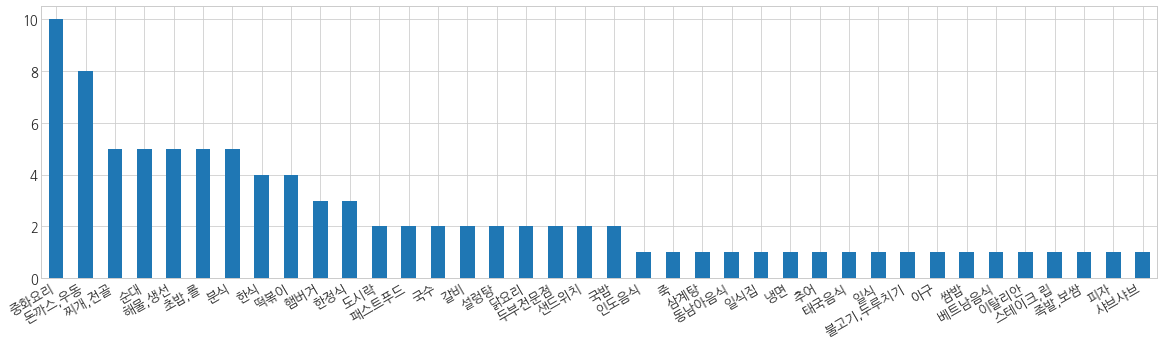

In [14]:
df_700.category.value_counts(ascending=False).plot('bar', figsize=(20, 5))
plt.xticks(rotation=30, ha='right')
plt.show()

* 의외로 중화요리가 제일 많다! 실제로 가본곳은 한 곳밖에 없는데! 몰랐다!
    * 그리도 돈까스집이 두 번째로 많고, 초밥집도 의외로 많다.
    * 초밥집도 두 군데밖에 못 봤는데!
* 중화요리집의 ZMS는 어떤지 살펴보자.

In [15]:
df_700_ch = df_700.query('category == "중화요리"')
df_700_ch

,name,category,address,score,eval_cnt,review_cnt,lat,lng,distance,ZMS
7,천지궁 서초점,중화요리,서초동 1589-8,3.5,28,23,37.485174,127.013142,679.771468,47.44
24,연화산,중화요리,서초동 1343-16,3.1,16,2,37.487185,127.026204,494.793723,34.23
29,명가교동짬뽕 서초점,중화요리,서초동 1599-2,3.0,13,4,37.486789,127.014534,541.772251,31.02
36,만다린,중화요리,서초동 1431-9,3.4,8,91,37.484176,127.021636,272.044145,30.29
52,황궁,중화요리,서초동 1601-1,2.8,10,9,37.486087,127.014473,548.085064,26.55
58,송쉐프 르쁘띠,중화요리,서초동 1577-6,4.3,4,18,37.489069,127.014051,649.645876,25.03
67,칭하이,중화요리,서초동 1443-25,2.3,9,25,37.485443,127.020136,126.228397,21.66
74,팔당반점 서초직영점,중화요리,서초동 1425-15,3.5,4,7,37.482749,127.019208,436.204545,20.18
81,강남짬뽕,중화요리,서초동 1602-10,2.0,9,24,37.485088,127.015821,455.070990,19.06
82,매화,중화요리,서초1동 1442-10,2.5,6,5,37.485338,127.021491,148.273532,18.56


* 10점대부터, 47점대까지 다양하게 분포되어있다.
* 점수만 봐서는 감이 한 번에 오지는 않는데,
    * 비교할만한 수치를 찾아보자.

In [16]:
# ZMS분포를 기준으로 특정 음식점이 몇%인지 알기 위한 그래프 그리기 함수 정의

# ZMS의 분포 그리기
import matplotlib.pyplot as plt
plt.rc('font', family='NanumGothic')
def dist_zms(df=df):
    plt.figure(figsize=(20, 5))
    plt.xlim(0, 100)
    sns.distplot(df['ZMS'])
    plt.title('Distribution ZMS', pad=40)
    plt.xlabel('')
# 분포에 음식점 추가하기
def add_zms(name, df=df):
    index_ = df[df.name==name].index[0]
    zms_ = df.iloc[index_, 9]

    plt.axvline(x=zms_, color='r', ls='--')
    plt.text(zms_, 0.04, str(round((index_+1)/len(df)*100,2))+'%', rotation=20)
    plt.text(zms_-1, -0.001*len(name), name, rotation=-30)


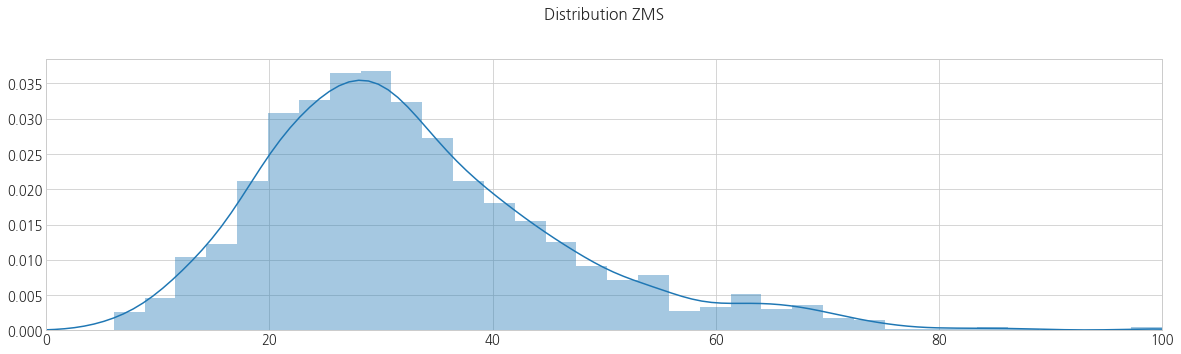

In [17]:
dist_zms()

* ZMS점수가 오른쪽으로 긴 꼬리 분포를 그리고 있으므로,
* 평균을 사용하면 엄격한 기준이 될 것 같다.
* 중앙값을 한번 구해보자.

In [18]:
print('평균: {:.2f}, 중앙값: {:.2f}'.format(df.ZMS.mean(), df.ZMS.median()))

평균: 32.78, 중앙값: 30.46


* 중앙값은 약 30점이다.
* ZMS가 30점보다 높은 음식점은 '괜찮은' 음식점일 가능성이 높다.
* 이제 다시 중화요리 카테고리로 돌아와서, 30점보다 높은 곳은 어디인지 살펴보자.

In [19]:
median_ZMS = df.ZMS.median()
df_700_ch_good = df_700_ch.query('ZMS > @median_ZMS')
df_700_ch_good

,name,category,address,score,eval_cnt,review_cnt,lat,lng,distance,ZMS
7,천지궁 서초점,중화요리,서초동 1589-8,3.5,28,23,37.485174,127.013142,679.771468,47.44
24,연화산,중화요리,서초동 1343-16,3.1,16,2,37.487185,127.026204,494.793723,34.23
29,명가교동짬뽕 서초점,중화요리,서초동 1599-2,3.0,13,4,37.486789,127.014534,541.772251,31.02


* 총 10곳 중, 괜찮다고 할 만한 곳은 총 3곳이다.
* 이 음식점들은 전체 식당 중 몇%인지 살펴보자.

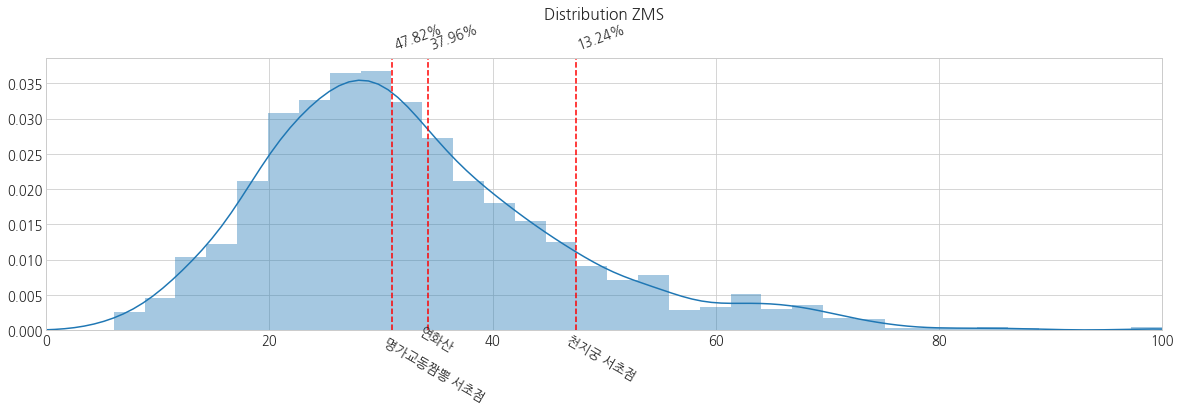

In [20]:
dist_zms()
for ch in df_700_ch_good.name:
    add_zms(ch)

* 천지궁은 상위 13% 음식점이고, 연화산과 교동짬뽕은 각각 38%, 48%로 중간 이상 정도의 음식점이다.
* 이제 이 음식점들이 어디에 위치해있는지 지도에 표시해보자.

In [21]:
m = aca_map()

for i in df_700_ch_good.index:
    lat = df_700_ch_good.loc[i, 'lat']
    lng = df_700_ch_good.loc[i, 'lng']
    name = df_700_ch_good.loc[i, 'name']
    folium.Marker([lat, lng], icon=folium.Icon(
            color='red', icon='heart-empty'), popup=name).add_to(m)
m


* 학원 남부터미널 부근과 학원 기준 오른쪽에 중화음식점이 위치하고있다!
* 10분 내외로 갈 수 있기때문에, 중화요리가 먹고싶은 날에는 학원 오른쪽에 있는 천지궁에 가보도록 하자.

### 2.3. 학원 근처의 괜찮은 음식점은?
* 이제 학원 커리큘럼이 끝나기 전, 꼭 가봐야할 음식점을 찾아보자.
* 그리고 그 음식점들의 리뷰를 분석하여, 실제로 어떤 평가를 받았는지 알아보자.

#### 2.3.1 음식점 분포 살펴보기
* 먼저, 학원 근처, 어느 곳에 음식점이 몰려있는지 알아보자.

In [22]:
df_700.head()

,name,category,address,score,eval_cnt,review_cnt,lat,lng,distance,ZMS
0,장꼬방,"찌개,전골",서초동 1438-8,3.2,299,124,37.486853,127.023648,266.307713,74.12
1,우작설렁탕,설렁탕,서초동 1621-5,3.7,106,57,37.486157,127.016108,403.677869,69.81
2,시골집,쌈밥,서울 서초구 반포대로10길 7,4.3,27,23,37.483737,127.012245,0.803824,57.25
3,삼보부대고기,"찌개,전골",서초1동 1443-27,4.1,22,16,37.485368,127.019386,168.767154,51.19
4,국대떡볶이 서초남부점,떡볶이,서초동 1443-1,3.4,40,8,37.485151,127.018561,238.360402,50.30


In [23]:
m = aca_map()
for i in df_700.index:
    lat, lng, name = df_700.lat[i], df_700.lng[i], df_700.name[i]
    folium.Marker([lat,lng], popup=name).add_to(m)
m

In [24]:
m = aca_map()
HeatMap(df_700[['lat', 'lng']], radius=20).add_to(m)
m

* 계산상의 오류일 것 같은데, 700m를 넘어가는 곳이 몇몇 곳 존재한다.
* 확실히 남부터미널역 부근에 많이 분포되어있다.

#### 2.3.2. 학원 근처, 괜찮은 음식점 찾아보기
* 먼저 학원 근처 top20 음식점을 찾아보고,
* 괜찮은 음식점은 어느 곳이 있는지 분석해보자.

In [25]:
for i in df_700[:20].index:
    lat = df_700[:20].loc[i, 'lat']
    lng = df_700[:20].loc[i, 'lng']
    name = df_700[:20].loc[i, 'name']
    folium.Marker([lat, lng], icon=folium.Icon(
            color='red', icon='heart-empty'), popup=name).add_to(m)
m

* 터미널 부근에 몰려있는 것을 알 수 있다.
* 몇 곳은 학원에서 길만 건너면 도착할 수 있다.
* top20곳의 ZMS 분포를 확인해보자.

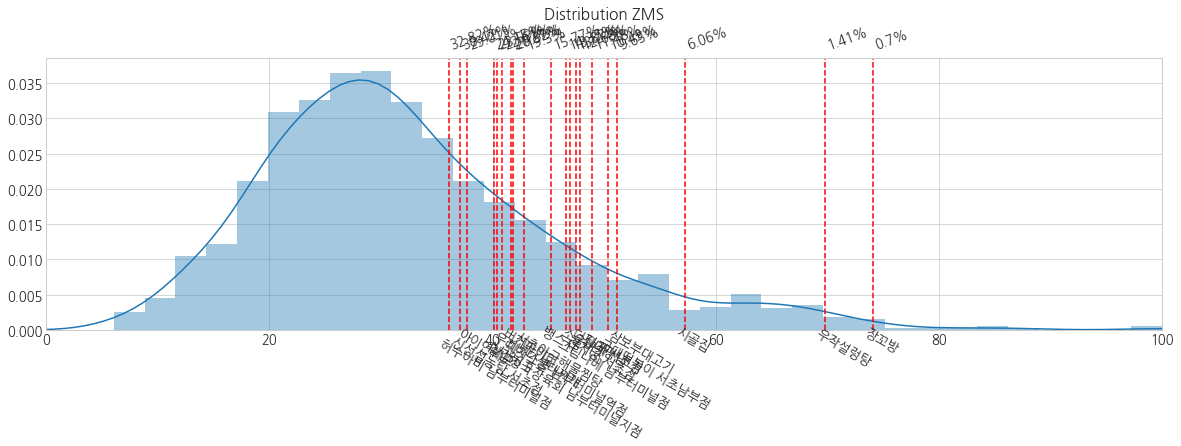

In [26]:
dist_zms()
for ch in df_700[:20].name:
    add_zms(ch)

In [27]:
df_700.head(20)

,name,category,address,score,eval_cnt,review_cnt,lat,lng,distance,ZMS
0,장꼬방,"찌개,전골",서초동 1438-8,3.2,299,124,37.486853,127.023648,266.307713,74.12
1,우작설렁탕,설렁탕,서초동 1621-5,3.7,106,57,37.486157,127.016108,403.677869,69.81
2,시골집,쌈밥,서울 서초구 반포대로10길 7,4.3,27,23,37.483737,127.012245,0.803824,57.25
3,삼보부대고기,"찌개,전골",서초1동 1443-27,4.1,22,16,37.485368,127.019386,168.767154,51.19
4,국대떡볶이 서초남부점,떡볶이,서초동 1443-1,3.4,40,8,37.485151,127.018561,238.360402,50.30
5,타지 서초점,인도음식,서초동 1444-21,3.7,26,22,37.484041,127.019181,302.915028,48.95
6,더진미평냉,냉면,서초동 1623-3,4.5,14,11,37.487126,127.015581,453.808097,47.87
7,천지궁 서초점,중화요리,서초동 1589-8,3.5,28,23,37.485174,127.013142,679.771468,47.44
8,소울버킷,햄버거,서초동 1578-4,4.6,12,49,37.488456,127.014277,604.102467,46.97
9,그림나베 남부터미널점,일식,서초동 1603-1,3.7,21,81,37.485729,127.016096,411.971397,46.61


* 모두 상위 30% 이상에 속한다.
    * 평균 이상일 것으로 예상되나, 정말 '괜찮을지'는 아직 장담할 수 없다.
* 기준을 조금 더 엄격하게 설정해보자.
* 전체 분포에서, 상위 20%보다 ZMS가 높은 곳들을 추려보자.

In [28]:
ZMS_20 = df.ZMS.quantile(.8)
ZMS_20

42.468

In [29]:
df_700_good = df_700[df_700.ZMS > ZMS_20]
df_700_good

,name,category,address,score,eval_cnt,review_cnt,lat,lng,distance,ZMS
0,장꼬방,"찌개,전골",서초동 1438-8,3.2,299,124,37.486853,127.023648,266.307713,74.12
1,우작설렁탕,설렁탕,서초동 1621-5,3.7,106,57,37.486157,127.016108,403.677869,69.81
2,시골집,쌈밥,서울 서초구 반포대로10길 7,4.3,27,23,37.483737,127.012245,0.803824,57.25
3,삼보부대고기,"찌개,전골",서초1동 1443-27,4.1,22,16,37.485368,127.019386,168.767154,51.19
4,국대떡볶이 서초남부점,떡볶이,서초동 1443-1,3.4,40,8,37.485151,127.018561,238.360402,50.30
5,타지 서초점,인도음식,서초동 1444-21,3.7,26,22,37.484041,127.019181,302.915028,48.95
6,더진미평냉,냉면,서초동 1623-3,4.5,14,11,37.487126,127.015581,453.808097,47.87
7,천지궁 서초점,중화요리,서초동 1589-8,3.5,28,23,37.485174,127.013142,679.771468,47.44
8,소울버킷,햄버거,서초동 1578-4,4.6,12,49,37.488456,127.014277,604.102467,46.97
9,그림나베 남부터미널점,일식,서초동 1603-1,3.7,21,81,37.485729,127.016096,411.971397,46.61


* 학원 근처에서 상위 20%에 해당하는 음식점은 총 12곳이 있다!
* 이 음식점들의 ZMS분포를 살펴보자.

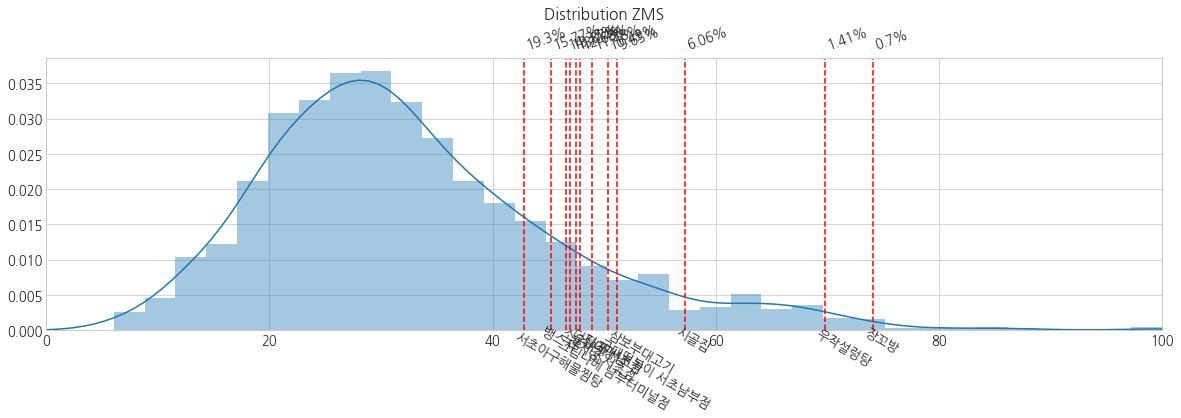

In [30]:
dist_zms()
for name in df_700_good.name:
    add_zms(name)

* 장꼬방이 상위 0.7%로 가장 점수가 높고, 우작설렁탕, 시골집도 10%안쪽으로 상위권이다.
* 그리고 나머지 음식점들은 10~20% 안팎에 몰려있는 것을 볼 수 있다.
* 이제 이 음식점들이 어디에 있는지 살펴보자.

In [31]:
m = aca_map()
for i in df_700_good[:3].index:
    lat = df_700_good.loc[i, 'lat']
    lng = df_700_good.loc[i, 'lng']
    name = df_700_good.loc[i, 'name']
    folium.Marker([lat, lng], icon=folium.Icon(
            color='red', icon='heart-empty'), popup=name).add_to(m)

for i in df_700_good[3:].index:
    lat = df_700_good.loc[i, 'lat']
    lng = df_700_good.loc[i, 'lng']
    name = df_700_good.loc[i, 'name']
    folium.Marker([lat, lng], icon=folium.Icon(
            color='orange', icon='heart-empty'), popup=name).add_to(m)
m

* top3는 빨간색으로, 나머지는 주황색으로 마커를 표시했다.
* 학원 커리큘럼이 끝나기 전에, 빨간 곳 3곳은 꼭 가보고,
* 여유가 된다면 나머지 주황색 음식점들도 모두 가보자.

### 2.4. 리뷰  분석해보기
* ZMS가 가장 높은 곳은 장꼬방, 그 다음은 우작설렁탕이었다.
* 이 두 곳의 리뷰를 분석하여, 
    * 별점의 변화를 알아보고
    * 어떤 리뷰들이 많이 달렸는지 확인해보자.

In [32]:
df_700.head(2)

,name,category,address,score,eval_cnt,review_cnt,lat,lng,distance,ZMS
0,장꼬방,"찌개,전골",서초동 1438-8,3.2,299,124,37.486853,127.023648,266.307713,74.12
1,우작설렁탕,설렁탕,서초동 1621-5,3.7,106,57,37.486157,127.016108,403.677869,69.81


#### 2.4.1. 리뷰 크롤링
* 먼저 리뷰를 크롤링해오자.

In [33]:
def crawler_for_review(review_num, url):
    from selenium import webdriver
    import time
    from bs4 import BeautifulSoup
    import pandas as pd
    
    def time_for_web(sleep=3):
        driver.implicitly_wait(10)
        time.sleep(sleep)
        
    driver = webdriver.Chrome('chromedriver/chromedriver.exe')
    time_for_web()
    # 리뷰 접속
    driver.get(url)
    time_for_web()
    
    temp = {'date': [], 'review': [], 'score': []}

    # 크롤링 시작
    for page in tqdm_notebook(range((review_num-1)//5+1)):
        time_for_web(sleep=2)
        soup = driver.page_source
        b = BeautifulSoup(soup, 'lxml')

        # 현재 페이지 정보 크롤링 - 레스토랑이 5개 미만이면 종료
        for i in range(5):
            try:
                temp['date'].append(pd.to_datetime(b.find_all(
                    'span', 'time_write')[i].text))    # 작성 날짜
                temp['review'].append(b.find_all('p', 'txt_comment')[i].text[:-3])    # 리뷰
                # 카카오플레이스에서 남긴 리뷰의 경우, 별점이 없음 > 0으로 대체
                try:
                    temp['score'].append(b.find_all('em', 'num_rate')[i+2].text[0])    # 평점
                except:
                    temp['score'].append(0)
                
            except:
                print('끝')
                break

        # 페이지 넘기기
        p = (page % 5)+1
        try:
            if page<5:
                if p // 5:
                    driver.find_element_by_css_selector(
                    '#mArticle > div.cont_evaluation > div.evaluation_review > div > a.btn_next').click()
                else:
                    driver.find_element_by_css_selector(
                        '#mArticle > div.cont_evaluation > div.evaluation_review \
                        > div > a:nth-child({})'.format(p+2)).click()
            elif p // 5:
                driver.find_element_by_css_selector(
                    '#mArticle > div.cont_evaluation > div.evaluation_review > div > a.btn_next').click()
            elif page:
                driver.find_element_by_css_selector(
                    '#mArticle > div.cont_evaluation > div.evaluation_review \
                    > div > a:nth-child({})'.format(p+3)).click()
        except:
            pass
    return pd.DataFrame(temp)

In [34]:
# review_jgb = crawler_for_review(302, 'https://place.map.kakao.com/8051506#comment')

In [35]:
# review_jgb.to_csv('source/Restaurant_analysis_miniproject/review_jgb.csv', index=False)
review_jgb = pd.read_csv('source/Restaurant_analysis_miniproject/review_jgb.csv')
review_jgb.shape

(302, 3)

In [36]:
# review_wj = crawler_for_review(106, 'https://place.map.kakao.com/8025479#comment')

In [37]:
# review_wj.to_csv('source/Restaurant_analysis_miniproject/review_wj.csv', index=False)
review_wj = pd.read_csv('source/Restaurant_analysis_miniproject/review_wj.csv')
review_wj.shape

(106, 3)

* 크롤링 완료!

#### 2.4.2. 별점 추이 분석하기
* ZMS가 높았던 음식점의 별점이 어떻게 변화했는지 알아보자.
* 먼저, date컬럼의 형식을 변경한 후, index로 설정해주자.

In [38]:
review_jgb.date = pd.to_datetime(review_jgb['date'])
review_wj.date = pd.to_datetime(review_wj['date'])

review_jgb.set_index('date', inplace=True)
review_wj.set_index('date', inplace=True)

In [39]:
review_jgb.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 302 entries, 2020-07-06 to 2010-03-27
Data columns (total 2 columns):
review    302 non-null object
score     302 non-null int64
dtypes: int64(1), object(1)
memory usage: 7.1+ KB


In [40]:
review_wj.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 106 entries, 2020-06-18 to 2009-01-18
Data columns (total 2 columns):
review    106 non-null object
score     106 non-null int64
dtypes: int64(1), object(1)
memory usage: 2.5+ KB


* 먼저, 장꼬방의 평가 추이를 살펴보자.
* 연,월 단위 기준으로, 평가를 얼마나 많이 받았나 보면, 어느 시점부터 유명해졌는지 알 수 있지 않을까?

In [41]:
len(review_wj['score'].resample('y').mean().index)

12

In [42]:
len(review_wj['score'].resample('y'))

12

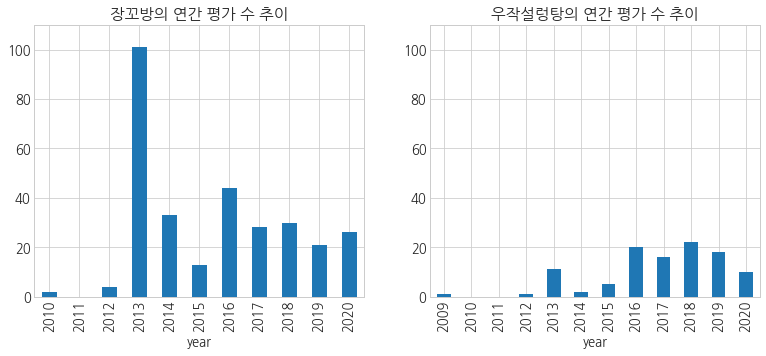

In [43]:
f, ax = plt.subplots(1, 2, figsize=(13, 5))
review_jgb['score'].resample('y').count().plot('bar', ax=ax[0])
ax[0].set_xticks(range(len(review_jgb['score'].resample('y'))))
ax[0].set_xticklabels(review_jgb['score'].resample('y').mean().index.year)
ax[0].set_xlabel('year')
ax[0].set_title('장꼬방의 연간 평가 수 추이')
ax[0].set_ylim(0, 110)

review_wj['score'].resample('y').count().plot('bar', ax=ax[1])
ax[1].set_xticks(range(len(review_wj['score'].resample('y'))))
ax[1].set_xticklabels(review_wj['score'].resample('y').mean().index.year)
ax[1].set_xlabel('year')
ax[1].set_title('우작설렁탕의 연간 평가 수 추이')
ax[1].set_ylim(0, 110)
plt.show()

* 위 그래프를 보면, 각 음식점이 언제 얼마나 평가를 받았는지 알 수 있다.
    * 평가는 장꼬방이 우작설렁탕보다 더 많이 받았다.
    * 장꼬방은 2013년에 가장 많은 평가를 받았고, 최근 3년간은 20~30회 정도의 평가를 받았다.
        * 그리고 평가 수가 들쑥날쑥임을 알 수 있다.
    * 우작 설렁탕은 2016년도부터 두각을 드러냈고, 이후 10~20건의 평가를 꾸준히 받고 있다.
* 사실 리뷰 수가 '좋은 음식점'을 나타낸다기보다는 '인지도'라고 이해하면 좋겠다.
* 그럼 이번엔 평점을 살펴보자.

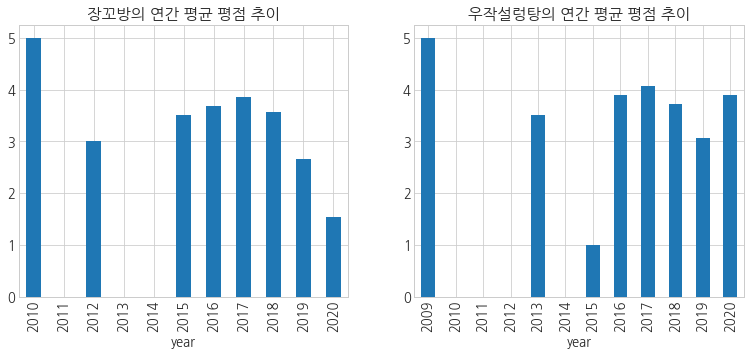

In [44]:
f, ax = plt.subplots(1, 2, figsize=(13, 5))
review_jgb[review_jgb.score!=0]['score'].resample('y').mean().fillna(0).plot('bar', ax=ax[0])
ax[0].set_xticks(range(len(review_jgb['score'].resample('y'))))
ax[0].set_xticklabels(review_jgb['score'].resample('y').mean().index.year)
ax[0].set_xlabel('year')
ax[0].set_title('장꼬방의 연간 평균 평점 추이')

review_wj[review_wj.score!=0]['score'].resample('y').mean().plot('bar', ax=ax[1])
ax[1].set_xticks(range(len(review_wj['score'].resample('y'))))
ax[1].set_xticklabels(review_wj['score'].resample('y').mean().index.year)
ax[1].set_xlabel('year')
ax[1].set_title('우작설렁탕의 연간 평균 평점 추이')

plt.show()

* 연간 평균 평점의 추이를 알 수 있다.
    * 장꼬방의 경우, 2017년에는 평균 평점이 3점 후반대였으나, 2020년에는 1점 중반대로 낮아졌다.
    * 반면, 우작설렁탕은, 최근 5년간 지속적으로 3~4점을 유지하고있다.
* 장꼬방은 왜 평점이 낮아지고있는지 살펴보고, 동시에 우작설렁탕의 리뷰도 분석해보자.

#### 2.4.3. 리뷰 형태소 분석 (장꼬방)

In [45]:
from konlpy.tag import Okt
okt = Okt()

In [46]:
sentences = []
for cp in tqdm_notebook(review_jgb.review):
    sentences.append(okt.pos(cp))

In [47]:
sentences[0]

[('8천원', 'Number'),
 ('따리', 'Foreign'),
 ('계란말이', 'Noun'),
 ('맛집', 'Noun'),
 ('입니다', 'Adjective'),
 ('!', 'Punctuation'),
 ('철분', 'Noun'),
 ('도', 'Josa'),
 ('함유', 'Noun'),
 ('되있고', 'Verb'),
 ('무엇', 'Noun'),
 ('보다', 'Josa'),
 ('수분', 'Noun'),
 ('보충', 'Noun'),
 ('해줘서', 'Verb'),
 ('몸', 'Noun'),
 ('에도', 'Josa'),
 ('좋아요', 'Adjective'),
 ('!', 'Punctuation')]

In [48]:
words = []
for sentence in tqdm_notebook(sentences):
    for word, tag in sentence:
        if tag not in ['Josa', 'Punctuation']:
            words.append(word)

In [49]:
from wordcloud import WordCloud
def makeWordcloud(words, cmap='RdBu', title=None):
    wordcloud = WordCloud(font_path='C:/Windows/Fonts/NanumGothic.ttf', background_color='white',
                          width=1500, colormap=cmap, height=1000).generate_from_frequencies(words)
    plt.figure(figsize=(15, 8))
    plt.title(title)
    plt.imshow(wordcloud)

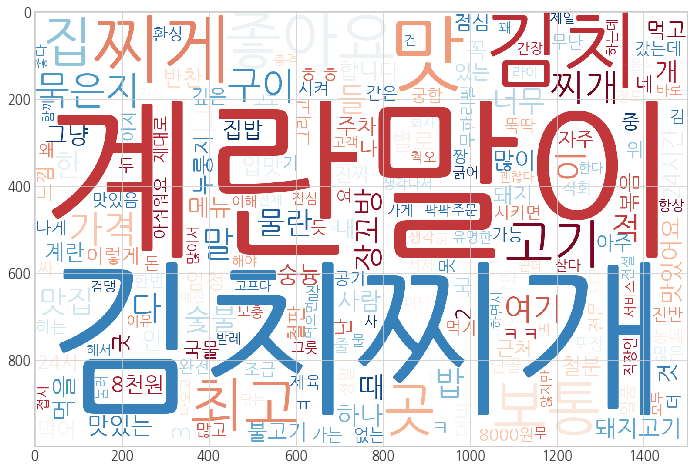

In [50]:
from collections import Counter
countword = Counter(words)
makeWordcloud(countword)

* 찌개집인데 계란말이의 언급이 더 많다.
* 이 시각화만으로는 비교가 어려우니, 긍정/부정을 나누어 시각화를 해보자.

In [51]:
len(review_jgb[review_jgb.score==5])

33

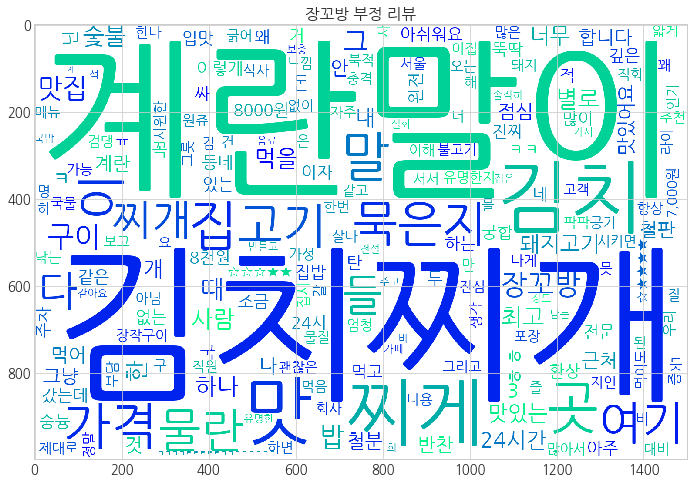

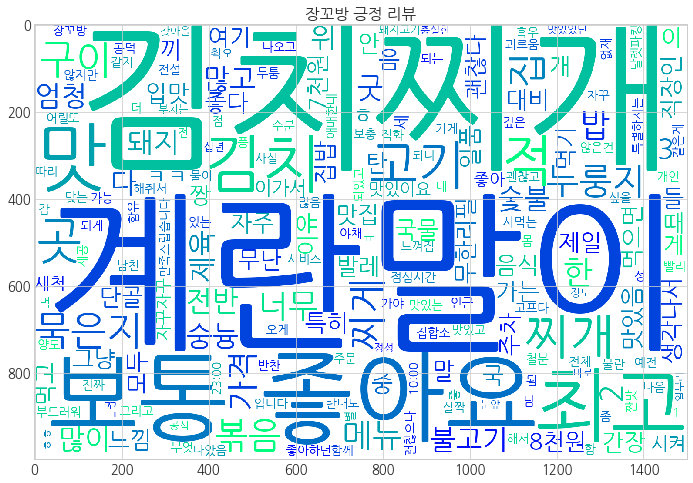

In [52]:
def makeWords(dataframe):
    sentences = []
    words = []
    for cp in tqdm_notebook(dataframe['review']):
        sentences.append(okt.pos(cp))
    for sentence in tqdm_notebook(sentences):
        for word, tag in sentence:
            if tag not in ['Josa', 'Punctuation']:
                words.append(word)
    return words
# 부정 리뷰
words_bad = makeWords(review_jgb[review_jgb.score<3])
countword_bad = Counter(words_bad)
makeWordcloud(countword_bad, cmap='winter', title='장꼬방 부정 리뷰')
# 긍정 리뷰
words_good = makeWords(review_jgb[review_jgb.score>=3])
countword_good = Counter(words_good)
makeWordcloud(countword_good, cmap='winter', title='장꼬방 긍정 리뷰')

* 긍정, 부정 리뷰 모두 김치찌개, 계란말이의 언급이 가장 많다.
* 찌개집이다보니 김치찌개의 언급은 이해가 되는데, 계란말이가 왜 이렇게 많이 언급되고있을까?
* 데이터가 적으니, 최근 리뷰를 직접 확인해보자.

In [53]:
review_jgb[review_jgb.index.year==2020]

,review,score
date,,
2020-07-06,8천원따리 계란말이 맛집입니다! 철분도 함유 되있고 무엇보다 수분 보충해줘서 몸에도...,5
2020-07-04,철분물란말이...,1
2020-07-03,솔직히 이정도로 줄서서 먹을집은 아님..,2
2020-06-30,계란말이 가격 실화인가요? 8000원 주고 물에 희석한 계란말이 먹을 바에 국밥 한...,1
2020-06-17,좋아요,4
2020-06-16,전설의 계란말이..,3
2020-06-11,전설의 물란말이,1
2020-06-08,철판 팍팍긁어 만들고 계란말이로 철판닦는 철분보충 물란말이,1
2020-05-20,물,1


* 계란말이에 대한 부정적인 리뷰가 잇다르고있다.
    * 특히 철분이 가득하다, 물이 너무 많이 들어갔다 라는 등의 이야기가 많다.
    * 부정리뷰 워드클라우드에서 '물란', '말' 등이라는 단어가 물란말이에서 왔음을 추측해볼 수 있다.
* 그럼 평점이 좋았던 2017년에는 어땠는지 살펴보자.

In [54]:
review_jgb[review_jgb.index.year==2017]

,review,score
date,,
2017-10-02,"계란말이 1위, 김치찌개 2위, 고기는 3위",4
2017-09-21,여기 김치찌개도 일품! 또 먹고프다~~,4
2017-09-01,보통이에요,3
2017-06-28,묵은지짱,5
2017-06-14,괜찮다. 별네개는 좀 애매한데. 불고기도 괜찮고 야채도 풍성 누룽지까지 제공되니 가...,4
2017-04-17,좋아요,4
2017-03-11,최고예요,5
2017-02-05,보통이에요,3
2017-01-13,김치찌개 7천원.계란말이 7천원.돼지숯불구이 8천원/10:00~23:00,4


* 전반적으로 짧은 리뷰가 많긴 하지만, 그래도 맛이 괜찮다는 평이 많다.
    * 평생 먹어본 계란말이 중 장꼬방의 계란말이가 가장 맛있다는 평까지 존재한다!
    * 정리하자면, 이전에는 김치찌개, 계란말이 맛집으로 유명했으나,
    * 초심을 지키지 못했거나 레시피의 변화 등으로 인해 부정적인 이미지를 안게된 것 같다.

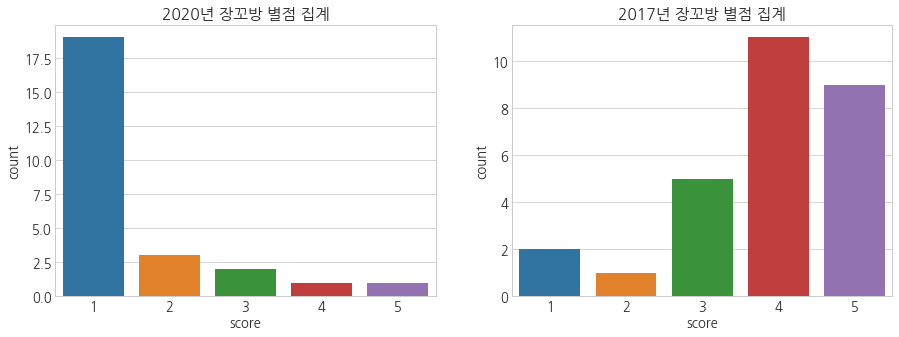

In [55]:
f, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.countplot(review_jgb[review_jgb.index.year==2020].score, ax=ax[0])
ax[0].set_title('2020년 장꼬방 별점 집계')
sns.countplot(review_jgb[review_jgb.index.year==2017].score, ax=ax[1])
ax[1].set_title('2017년 장꼬방 별점 집계')
plt.show()

* 위 그래프 하나가 모든것을 설명해주는듯..

#### 2.4.4. 리뷰 형태소 분석 (우작설렁탕)
* 다음으로는 우작설렁탕의 리뷰를 분석해보자.

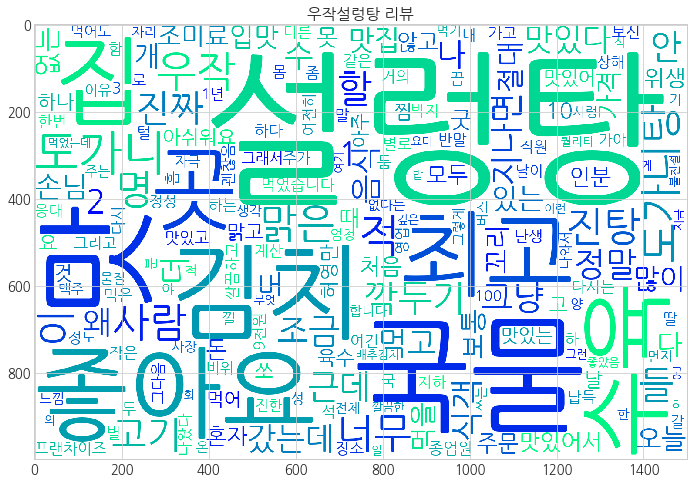

In [56]:
words_wj = makeWords(review_wj)
countword_wj = Counter(words_wj)
makeWordcloud(countword_wj, cmap='winter', title='우작설렁탕 리뷰')

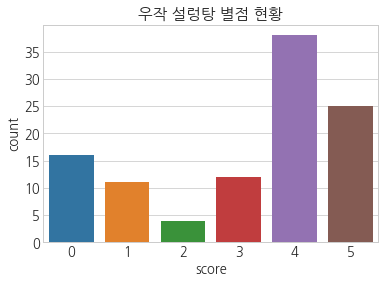

In [57]:
sns.countplot(review_wj.score)
plt.title('우작 설렁탕 별점 현황')
plt.show()

* 우작설렁탕은 장꼬방과 다르게, 4-5점의 분포가 가장 높다.
    * 설렁탕, 국물, 김치 등의 단어가 많이 나오며,
    * 좋아요, 맛, 최고 등의 긍정 단어가 많이 나오는 것을 확인해볼 수 있다.

### 2.5. 그래서 최고의 맛집은?
* 딱 한 군데만 뽑아야 한다면, 어디를 가야할까?

In [58]:
df_wj = df[df.name == '우작설렁탕']
m = aca_map(zoom=17)
folium.Marker([df_wj.lat, df_wj.lng], icon=folium.Icon(
        color='red', icon='heart-empty'), popup=df_wj.name).add_to(m)
m

* 이 곳에 위치한 우작설렁탕입니다!

In [59]:
df_700_good.drop(0, axis=0).reset_index(drop=True).to_csv('source/Restaurant_analysis_miniproject/lunch_200714.csv', index=False)

## 3. 점심에 갈 만한 일식집은 어디일까?
* 스시나 사케동 등을 먹고싶은데, 눈에 보이는 곳들이 많지 않다.
* 학원 근처에 있는 일식집을 찾아보자.

In [60]:
df_700.head()

,name,category,address,score,eval_cnt,review_cnt,lat,lng,distance,ZMS
0,장꼬방,"찌개,전골",서초동 1438-8,3.2,299,124,37.486853,127.023648,266.307713,74.12
1,우작설렁탕,설렁탕,서초동 1621-5,3.7,106,57,37.486157,127.016108,403.677869,69.81
2,시골집,쌈밥,서울 서초구 반포대로10길 7,4.3,27,23,37.483737,127.012245,0.803824,57.25
3,삼보부대고기,"찌개,전골",서초1동 1443-27,4.1,22,16,37.485368,127.019386,168.767154,51.19
4,국대떡볶이 서초남부점,떡볶이,서초동 1443-1,3.4,40,8,37.485151,127.018561,238.360402,50.30


### 3.1. 일식집 필터링
* 일단, 일식집을 찾기 위해서 카테고리를 확인해보자.

In [61]:
df

,name,category,address,score,eval_cnt,review_cnt,lat,lng,distance,ZMS
0,크래프트아일랜드 강남역점,"호프,요리주점",서초동 1317-32,4.8,173,292,37.498478,127.025597,1401.450583,100.00
1,크래버 대게나라 서초점,"게,대게",서초동 1582-16,4.8,166,101,37.486660,127.010803,870.179020,98.60
2,미즈컨테이너 강남웨스트점,양식,서초동 1316-29,3.4,603,354,37.498270,127.025215,1369.162723,88.51
3,영동족발 3호점,"족발,보쌈",양재동 1-8,3.5,410,105,37.484180,127.038309,1578.216483,85.02
4,마키노차야 역삼점,해산물뷔페,역삼동 824-46,3.6,322,210,37.498140,127.031071,1587.181976,84.38
...,...,...,...,...,...,...,...,...,...,...
1415,명랑핫도그 서초우성점,패스트푸드,서초동 1337-14,1.0,5,2,37.492195,127.029043,973.573941,6.94
1416,로봇김밥 신분당선양재역점,분식,양재동,1.0,4,8,37.473198,127.038170,2138.641337,6.71
1417,배수경양재정육식당 17호점,"육류,고기",양재동 13-13,1.0,5,0,37.482996,127.036419,1443.782964,6.29
1418,파스쿠찌 교대메가스터디점,커피전문점,서초동 1671-2,1.0,4,3,37.493280,127.014626,923.268458,6.23


In [62]:
df_700.category.unique()

array(['찌개,전골', '설렁탕', '쌈밥', '떡볶이', '인도음식', '냉면', '중화요리', '햄버거', '일식',
       '초밥,롤', '아구', '피자', '한식', '스테이크,립', '돈까스,우동', '갈비', '베트남음식',
       '동남아음식', '도시락', '해물,생선', '추어', '불고기,두루치기', '두부전문점', '태국음식', '분식',
       '족발,보쌈', '순대', '패스트푸드', '샌드위치', '한정식', '이탈리안', '샤브샤브', '삼계탕',
       '닭요리', '국수', '죽', '일식집', '국밥'], dtype=object)

* 위의 카테고리 중에서 
    * '일식', '초밥,롤', '일식집' 을 '일식'으로 묶어서 분석해보자.

In [63]:
df_jp = df_700.query("category in ('일식', '초밥,롤', '일식집')").reset_index(drop=True)
df_jp

,name,category,address,score,eval_cnt,review_cnt,lat,lng,distance,ZMS
0,그림나베 남부터미널점,일식,서초동 1603-1,3.7,21,81,37.485729,127.016096,411.971397,46.61
1,뱅스시,"초밥,롤",서초동 1458-6,4.4,12,71,37.484206,127.013679,666.867820,45.24
2,스시36.5,"초밥,롤",서초동 1603-69,5.0,7,34,37.485566,127.017826,270.972268,40.11
3,스시환,"초밥,롤",서초동 1603-20,2.8,22,39,37.485425,127.016262,406.205125,35.99
4,스시마카세,"초밥,롤",서초동 1603-1,3.8,10,5,37.485729,127.016096,411.971397,35.25
5,도라스시,"초밥,롤",(지번) 서초동 1360-18,3.0,12,46,37.486762,127.032122,1.011351,31.39
6,최수사,일식집,서초동 1443-32,3.0,5,2,37.485213,127.018779,219.193578,19.51


### 3.2. ZMS 확인하기
* 위 7곳 음식점의 ZMS 분포를 확인해보자.

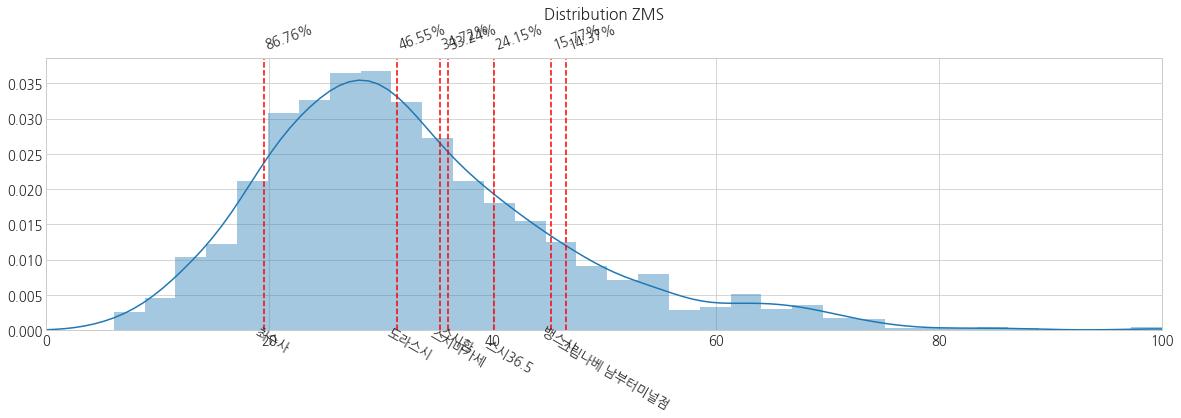

In [64]:
dist_zms()
for ch in df_jp.name:
    add_zms(ch)

* 최수사 라는 곳을 제외하면, 평균 이상의 음식점이라고 할 수 있다.
* 그림나베와 뱅스시는 상위 15%정도로, 괜찮은 음식점이다.

## 4. 인터랙티브 지도 시각화
* with plotly library

In [65]:
import ipywidgets as widgets
from ipywidgets import interact

# 이걸 설정하면 Multiple Output이 가능함
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

In [66]:
def visualize_by_date(df):
    interact(aca_map, date=list(np.sort(df['date'].unique())))

In [67]:
df_jp.head(3)

,name,category,address,score,eval_cnt,review_cnt,lat,lng,distance,ZMS
0,그림나베 남부터미널점,일식,서초동 1603-1,3.7,21,81,37.485729,127.016096,411.971397,46.61
1,뱅스시,"초밥,롤",서초동 1458-6,4.4,12,71,37.484206,127.013679,666.867820,45.24
2,스시36.5,"초밥,롤",서초동 1603-69,5.0,7,34,37.485566,127.017826,270.972268,40.11


In [68]:
df_jp

,name,category,address,score,eval_cnt,review_cnt,lat,lng,distance,ZMS
0,그림나베 남부터미널점,일식,서초동 1603-1,3.7,21,81,37.485729,127.016096,411.971397,46.61
1,뱅스시,"초밥,롤",서초동 1458-6,4.4,12,71,37.484206,127.013679,666.867820,45.24
2,스시36.5,"초밥,롤",서초동 1603-69,5.0,7,34,37.485566,127.017826,270.972268,40.11
3,스시환,"초밥,롤",서초동 1603-20,2.8,22,39,37.485425,127.016262,406.205125,35.99
4,스시마카세,"초밥,롤",서초동 1603-1,3.8,10,5,37.485729,127.016096,411.971397,35.25
5,도라스시,"초밥,롤",(지번) 서초동 1360-18,3.0,12,46,37.486762,127.032122,1.011351,31.39
6,최수사,일식집,서초동 1443-32,3.0,5,2,37.485213,127.018779,219.193578,19.51


In [69]:
df_jp_good = df_jp[df_jp['ZMS']>=20]
df_jp_good

,name,category,address,score,eval_cnt,review_cnt,lat,lng,distance,ZMS
0,그림나베 남부터미널점,일식,서초동 1603-1,3.7,21,81,37.485729,127.016096,411.971397,46.61
1,뱅스시,"초밥,롤",서초동 1458-6,4.4,12,71,37.484206,127.013679,666.867820,45.24
2,스시36.5,"초밥,롤",서초동 1603-69,5.0,7,34,37.485566,127.017826,270.972268,40.11
3,스시환,"초밥,롤",서초동 1603-20,2.8,22,39,37.485425,127.016262,406.205125,35.99
4,스시마카세,"초밥,롤",서초동 1603-1,3.8,10,5,37.485729,127.016096,411.971397,35.25
5,도라스시,"초밥,롤",(지번) 서초동 1360-18,3.0,12,46,37.486762,127.032122,1.011351,31.39


In [70]:
df_jp_good.to_csv('source/Restaurant_analysis_miniproject/jp_restaurant_200714.csv', index=False)
df_jp_good = pd.read_csv('source/Restaurant_analysis_miniproject/jp_restaurant_200714.csv')
df_jp_good

,name,category,address,score,eval_cnt,review_cnt,lat,lng,distance,ZMS
0,그림나베 남부터미널점,일식,서초동 1603-1,3.7,21,81,37.485729,127.016096,411.971397,46.61
1,뱅스시,"초밥,롤",서초동 1458-6,4.4,12,71,37.484206,127.013679,666.867820,45.24
2,스시36.5,"초밥,롤",서초동 1603-69,5.0,7,34,37.485566,127.017825,270.972268,40.11
3,스시환,"초밥,롤",서초동 1603-20,2.8,22,39,37.485425,127.016262,406.205125,35.99
4,스시마카세,"초밥,롤",서초동 1603-1,3.8,10,5,37.485729,127.016096,411.971397,35.25
5,도라스시,"초밥,롤",(지번) 서초동 1360-18,3.0,12,46,37.486762,127.032122,1.011351,31.39


In [71]:
m

In [72]:
def jp_by_zms(df):
    def view_map(ZMS, cat, dis):
        data = df[df['ZMS'] >= ZMS][df['category'] == cat][df['distance'] <= dis]
        m = aca_map(zoom=15)
        for i in data.index:
            lat = data.loc[i, 'lat']
            lng = data.loc[i, 'lng']
            name = data.loc[i, 'name']
            folium.Marker([lat, lng], icon=folium.Icon(
                color='orange', icon='heart-empty'), popup=name).add_to(m)
        return m
    interact(view_map, 
             ZMS = widgets.IntSlider(min=0, max=100, step=1, value=30), 
             cat = list(df.category.unique()),
             dis = widgets.IntSlider(min=0, max=max(df.distance), step=10, value=700))
    
jp_by_zms(df_jp)

interactive(children=(IntSlider(value=30, description='ZMS'), Dropdown(description='cat', options=('일식', '초밥,롤…

In [73]:
type(m)

folium.folium.Map

In [74]:
import chart_studio.plotly as py 
import plotly.express as px
import cufflinks as cf 
cf.go_offline(connected=True)

In [75]:
df_jp.ZMS.iplot()

In [76]:
df_ys = pd.read_csv('source/Restaurant_analysis_miniproject/0713_02_ys.csv.txt')
df_ys.head()

,name,category,address,score,eval_cnt,review_cnt,lat,lng,distance,ZMS,new_category,walking_min
0,시골집,쌈밥,서울 서초구 반포대로10길 7,4.3,27,23,37.483737,127.012245,803.823780,57.25,"백반, 한정식",10
1,순남시래기 양재점,한정식,서초동 1363-25,4.0,18,48,37.485601,127.031665,975.876261,47.47,"백반, 한정식",15
2,남도랑,한정식,역삼동 830-22,3.9,16,2,37.494105,127.032148,1319.963173,42.90,"백반, 한정식",20
3,고등어식당,한식,역삼동 824-25,4.5,10,1,37.497514,127.031060,1530.325117,40.90,"백반, 한정식",25
4,남도미락,한식,서초동 1706-12,4.0,12,8,37.493538,127.009152,1282.308598,40.13,"백반, 한정식",19


In [77]:
aca_geo = (37.486498, 127.020663)
lat100m = 0.000899
lng100m = 0.001134

In [78]:
df_full = pd.read_csv('source/Restaurant_analysis_miniproject/0714_category_full.csv', index_col=0)
df_full.shape

(174, 12)

In [79]:
df_full

,name,category,address,score,eval_cnt,review_cnt,lat,lng,distance,ZMS,new_category,walking_min
0,시골집,쌈밥,서울 서초구 반포대로10길 7,4.3,27,23,37.483737,127.012245,803.823780,57.25,"백반, 한정식",10
1,순남시래기 양재점,한정식,서초동 1363-25,4.0,18,48,37.485601,127.031665,975.876261,47.47,"백반, 한정식",15
2,남도랑,한정식,역삼동 830-22,3.9,16,2,37.494105,127.032148,1319.963173,42.90,"백반, 한정식",20
3,고등어식당,한식,역삼동 824-25,4.5,10,1,37.497514,127.031060,1530.325117,40.90,"백반, 한정식",25
4,남도미락,한식,서초동 1706-12,4.0,12,8,37.493538,127.009152,1282.308598,40.13,"백반, 한정식",19
...,...,...,...,...,...,...,...,...,...,...,...,...
169,천지궁 서초점,중화요리,서초동 1589-8,3.5,28,23,37.485174,127.013142,679.771468,47.44,점심추천,9
170,소울버킷,햄버거,서초동 1578-4,4.6,12,49,37.488456,127.014277,604.102467,46.97,점심추천,7
171,그림나베 남부터미널점,일식,서초동 1603-1,3.7,21,81,37.485729,127.016096,411.971397,46.61,점심추천,6
172,뱅스시,"초밥,롤",서초동 1458-6,4.4,12,71,37.484206,127.013679,666.867820,45.24,점심추천,8


In [80]:
import plotly.graph_objects as go


def aca_trace(figure, m, t, c='gray', o=.2):
    aca_geo = (37.486498, 127.020663)
    lat100m = 0.000899
    lng100m = 0.001134
    lat0 = aca_geo[0] - lat100m * m
    lat1 = aca_geo[0] + lat100m * m
    lng0 = aca_geo[1] - lng100m * m
    lng1 = aca_geo[1] + lng100m * m
    figure.add_trace(go.Scattermapbox(
        mode="markers+lines", 
        showlegend=False,
        opacity=o,
        lat=[lat0, lat0, lat1, lat1, lat0],
        lon=[lng0, lng1, lng1, lng0, lng0],
        marker={'color': c},
        hovertemplate='도보 {}분'.format(t),
        name='학원 근처 {}00m'.format(m)))

fig = px.scatter_mapbox(df_full, lat="lat", lon="lng", zoom=14,
                        size='ZMS', size_max=15, hover_name='name', hover_data=['walking_min'],
                        color='new_category',
                        mapbox_style='carto-positron', width=1000, height=1000,
                        center={'lat': df_full.lat.mean(), 'lon': df_full.lng.mean()})
aca_trace(fig, 1, 1, c='black', o=.5)
aca_trace(fig, 3, 5, o=.5)
aca_trace(fig, 7, 10, o=.3)
fig.show()
# fig.update_layout(
#     mapbox = {'style': "stamen-terrain", 'center': {'lon': aca_geo[1], 'lat': aca_geo[0]}, 'zoom': 15},
#     showlegend = False, 
#     margin = {'l':0, 'r':0, 'b':0, 't':0})

# fig.show()

In [81]:
df_1000 = pd.read_csv('source/Restaurant_analysis_miniproject/1000m.csv')
df_1000.shape

(509, 12)

In [82]:
df.ZMS.quantile(0.9)    # 꼭 가봐야할 곳 상위 10%
df.ZMS.quantile(0.7)    # 맛집! 상위 30%
df.ZMS.quantile(0.5)    # 평범한 곳
df.ZMS.quantile(0.3)    # 추천하지 않아요.

50.85600000000001

37.28

30.46

25.087

In [83]:
df_1000['grade'] = np.where(df_1000.ZMS >= df.ZMS.quantile(0.9), '꼭 가봐야할 곳 - 상위 10%',
                            np.where(df_1000.ZMS >= df.ZMS.quantile(0.7), '맛집 - 상위 30%',
                                     np.where(df_1000.ZMS >= df.ZMS.quantile(0.5), '평범한 곳 - 50% 이상',
                                              np.where(df_1000.ZMS >= df.ZMS.quantile(0.3), '마음의 준비 - 하위 30~50% ', '비추천 - 하위 30% 미만'))))
df_1000

,name,category,address,score,eval_cnt,review_cnt,lat,lng,distance,ZMS,new_category,walking_min,grade
0,크래버 대게나라 서초점,"게,대게",서초동 1582-16,4.8,166,101,37.486660,127.010803,870.179020,98.60,해물,14,꼭 가봐야할 곳 - 상위 10%
1,세광양대창 교대본점 본관,"곱창,막창",서초동 1571-19,4.7,63,151,37.491970,127.012569,938.172496,79.05,고기,14,꼭 가봐야할 곳 - 상위 10%
2,유타로 강남점,일본식라면,서초동 1330-6,3.8,133,138,37.493030,127.028392,996.261130,75.52,국수,16,꼭 가봐야할 곳 - 상위 10%
3,장꼬방,"찌개,전골",서초동 1438-8,3.2,299,124,37.486853,127.023648,266.307713,74.12,한식,4,꼭 가봐야할 곳 - 상위 10%
4,백년옥 본관,두부전문점,서초동 1450-6,3.3,232,329,37.481151,127.013769,850.610606,73.65,한식,13,꼭 가봐야할 곳 - 상위 10%
...,...,...,...,...,...,...,...,...,...,...,...,...,...
504,파스쿠찌 뱅뱅사거리점,커피전문점,서초동 1340-11,1.8,4,1,37.488847,127.030971,946.242938,10.16,"카페, 간식",13,비추천 - 하위 30% 미만
505,명인만두 남부터미널점,분식,서초동 1601-1,1.7,4,0,37.486087,127.014473,548.085064,9.21,분식,8,비추천 - 하위 30% 미만
506,명인만두 뱅뱅사거리점,분식,서초동 1337-22,1.0,5,2,37.491470,127.029961,989.256607,6.94,분식,14,비추천 - 하위 30% 미만
507,명랑핫도그 서초우성점,패스트푸드,서초동 1337-14,1.0,5,2,37.492195,127.029043,973.573941,6.94,양식,15,비추천 - 하위 30% 미만


In [84]:
tmp = 37
len(df_1000[df_1000.ZMS > tmp])

137

In [85]:
df_1000

,name,category,address,score,eval_cnt,review_cnt,lat,lng,distance,ZMS,new_category,walking_min,grade
0,크래버 대게나라 서초점,"게,대게",서초동 1582-16,4.8,166,101,37.486660,127.010803,870.179020,98.60,해물,14,꼭 가봐야할 곳 - 상위 10%
1,세광양대창 교대본점 본관,"곱창,막창",서초동 1571-19,4.7,63,151,37.491970,127.012569,938.172496,79.05,고기,14,꼭 가봐야할 곳 - 상위 10%
2,유타로 강남점,일본식라면,서초동 1330-6,3.8,133,138,37.493030,127.028392,996.261130,75.52,국수,16,꼭 가봐야할 곳 - 상위 10%
3,장꼬방,"찌개,전골",서초동 1438-8,3.2,299,124,37.486853,127.023648,266.307713,74.12,한식,4,꼭 가봐야할 곳 - 상위 10%
4,백년옥 본관,두부전문점,서초동 1450-6,3.3,232,329,37.481151,127.013769,850.610606,73.65,한식,13,꼭 가봐야할 곳 - 상위 10%
...,...,...,...,...,...,...,...,...,...,...,...,...,...
504,파스쿠찌 뱅뱅사거리점,커피전문점,서초동 1340-11,1.8,4,1,37.488847,127.030971,946.242938,10.16,"카페, 간식",13,비추천 - 하위 30% 미만
505,명인만두 남부터미널점,분식,서초동 1601-1,1.7,4,0,37.486087,127.014473,548.085064,9.21,분식,8,비추천 - 하위 30% 미만
506,명인만두 뱅뱅사거리점,분식,서초동 1337-22,1.0,5,2,37.491470,127.029961,989.256607,6.94,분식,14,비추천 - 하위 30% 미만
507,명랑핫도그 서초우성점,패스트푸드,서초동 1337-14,1.0,5,2,37.492195,127.029043,973.573941,6.94,양식,15,비추천 - 하위 30% 미만


In [86]:
df_top12 = df.iloc[[19, 24, 21, 534, 85, 6, 181, 156, 343, 197, 319, 351], :].reset_index(drop=True)
df_top12

,name,category,address,score,eval_cnt,review_cnt,lat,lng,distance,ZMS
0,우작설렁탕,설렁탕,서초동 1621-5,3.7,106,57,37.486157,127.016108,403.677869,69.81
1,루엘드파리,"제과,베이커리",서초동 1445-13,3.9,72,267,37.484014,127.017342,402.732947,68.46
2,탐라도야지,"육류,고기",서초3동 1566-8,4.0,70,220,37.489555,127.013545,714.110608,69.58
3,사람사는 고깃집 김일도 서초점,"육류,고기",서초동 1594-3,3.9,8,105,37.486548,127.013985,589.236247,34.43
4,시골집,쌈밥,서울 서초구 반포대로10길 7,4.3,27,23,37.483737,127.012245,0.803824,57.25
5,세광양대창 교대본점 본관,"곱창,막창",서초동 1571-19,4.7,63,151,37.491970,127.012569,938.172496,79.05
6,선궁,중화요리,서초동 1451-34,3.9,20,36,37.482641,127.012799,815.672905,47.78
7,설눈,냉면,서초동 1551-9,4.0,20,117,37.491197,127.009756,1095.026649,49.63
8,광해즉석떡볶이,떡볶이,서초동 1716-10,4.0,11,86,37.493330,127.011681,1097.833992,40.11
9,뽕족 강남점,"족발,보쌈",역삼동 826-7,4.1,16,73,37.496024,127.029444,1312.326048,46.95


In [87]:
df_1000.head(1)

,name,category,address,score,eval_cnt,review_cnt,lat,lng,distance,ZMS,new_category,walking_min,grade
0,크래버 대게나라 서초점,"게,대게",서초동 1582-16,4.8,166,101,37.48666,127.010803,870.17902,98.6,해물,14,꼭 가봐야할 곳 - 상위 10%


In [88]:
df_top12['walking_min'] = [6, 6, 9, 9, 10, 11, 11, 15, 17, 22, 25, 25]
df_top12['new_category'] = ['국밥', '카페, 간식', '고기', '고기',
                            '백반', '고기', '중식', '국수', '분식', '족발', '백반', '국수']
df_top12['menu_rcmd'] = ['설렁탕',
                         '치아바타, 아몬드 크로아상',
                         '삼겹살, 된장찌게',
                         '김일도 한판, 점심',
                         '제육쌈밥',
                         '특양, 곱창전골, 양볶음밥',
                         '짜장, 짬뽕, 요리',
                         '물냉면, 수육',
                         '불맛 가득 떡볶이',
                         '모둠 족발',
                         '제육, 고등어 구이',
                         '모든 국수, 보쌈']
df_top12

,name,category,address,score,eval_cnt,review_cnt,lat,lng,distance,ZMS,walking_min,new_category,menu_rcmd
0,우작설렁탕,설렁탕,서초동 1621-5,3.7,106,57,37.486157,127.016108,403.677869,69.81,6,국밥,설렁탕
1,루엘드파리,"제과,베이커리",서초동 1445-13,3.9,72,267,37.484014,127.017342,402.732947,68.46,6,"카페, 간식","치아바타, 아몬드 크로아상"
2,탐라도야지,"육류,고기",서초3동 1566-8,4.0,70,220,37.489555,127.013545,714.110608,69.58,9,고기,"삼겹살, 된장찌게"
3,사람사는 고깃집 김일도 서초점,"육류,고기",서초동 1594-3,3.9,8,105,37.486548,127.013985,589.236247,34.43,9,고기,"김일도 한판, 점심"
4,시골집,쌈밥,서울 서초구 반포대로10길 7,4.3,27,23,37.483737,127.012245,0.803824,57.25,10,백반,제육쌈밥
5,세광양대창 교대본점 본관,"곱창,막창",서초동 1571-19,4.7,63,151,37.491970,127.012569,938.172496,79.05,11,고기,"특양, 곱창전골, 양볶음밥"
6,선궁,중화요리,서초동 1451-34,3.9,20,36,37.482641,127.012799,815.672905,47.78,11,중식,"짜장, 짬뽕, 요리"
7,설눈,냉면,서초동 1551-9,4.0,20,117,37.491197,127.009756,1095.026649,49.63,15,국수,"물냉면, 수육"
8,광해즉석떡볶이,떡볶이,서초동 1716-10,4.0,11,86,37.493330,127.011681,1097.833992,40.11,17,분식,불맛 가득 떡볶이
9,뽕족 강남점,"족발,보쌈",역삼동 826-7,4.1,16,73,37.496024,127.029444,1312.326048,46.95,22,족발,모둠 족발


In [89]:
def aca_trace(figure, m, t, c='gray', o=.2):
    aca_geo = (37.486498, 127.020663)
    lat100m = 0.000899
    lng100m = 0.001134
    lat0 = aca_geo[0] - lat100m * m
    lat1 = aca_geo[0] + lat100m * m
    lng0 = aca_geo[1] - lng100m * m
    lng1 = aca_geo[1] + lng100m * m
    figure.add_trace(go.Scattermapbox(
        mode="markers+lines", 
        showlegend=False,
        opacity=o,
        lat=[lat0, lat0, lat1, lat1, lat0],
        lon=[lng0, lng1, lng1, lng0, lng0],
        marker={'color': c},
        hovertemplate='도보 {}분'.format(t),
        name='학원 근처 {}00m'.format(m)))

fig = px.scatter_mapbox(df_top12, lat="lat", lon="lng", zoom=14.3,
                        size='ZMS', size_max=15, hover_name='name', hover_data=['menu_rcmd','walking_min'],
                        color='new_category',
                        mapbox_style='carto-positron', width=1000, height=1000,
                        center={'lat': 37.486498, 'lon': 127.020663})
aca_trace(fig, 1, 1, c='black', o=.5)
aca_trace(fig, 3, 5, o=.5)
aca_trace(fig, 7, 10, o=.3)
fig.show()

In [119]:
df_chicken = df[df.category == '치킨']

df_chicken['grade'] = np.where(df_chicken.ZMS >= df.ZMS.quantile(0.9), '꼭 가봐야할 곳 - 상위 10%',
                            np.where(df_chicken.ZMS >= df.ZMS.quantile(0.7), '맛집 - 상위 30%',
                                     np.where(df_chicken.ZMS >= df.ZMS.quantile(0.5), '평범한 곳 - 50% 이상',
                                              np.where(df_chicken.ZMS >= df.ZMS.quantile(0.3), '마음의 준비 - 하위 30~50% ', '비추천 - 하위 30% 미만'))))
df_chicken

,name,category,address,score,eval_cnt,review_cnt,lat,lng,distance,ZMS,walking_min,grade
48,양재닭집,치킨,양재동 1-7,3.1,157,93,37.484274,127.037952,1545.407157,63.92,22.0,꼭 가봐야할 곳 - 상위 10%
137,바른치킨 남부터미널점,치킨,서초동 1458-6,4.2,20,28,37.484206,127.013679,666.867820,51.15,8.0,꼭 가봐야할 곳 - 상위 10%
191,캔프치킨,치킨,서초동 1578-1,4.2,16,20,37.488797,127.014002,640.891454,47.29,8.0,맛집 - 상위 30%
277,모던통닭 역삼점,치킨,역삼동 827-24,3.0,30,105,37.495492,127.031590,1389.066165,42.61,22.0,맛집 - 상위 30%
304,꼬꼬아찌숯불치킨 강남역점,치킨,역삼동 817-8,3.7,15,58,37.500275,127.027638,1650.881159,41.55,28.0,맛집 - 상위 30%
332,오븐에빠진닭 강남2호점,치킨,역삼동 818-3,3.3,20,20,37.499791,127.028277,1623.553695,40.42,28.0,맛집 - 상위 30%
382,조가홍닭 남부터미널점,치킨,서초동 1601-2,4.4,9,5,37.485765,127.014686,533.616385,38.83,8.0,맛집 - 상위 30%
401,더대박치킨 서초점,치킨,서초동 1600-7,4.6,8,3,37.486127,127.015103,492.281451,38.19,7.0,맛집 - 상위 30%
498,노랑통닭 교대점,치킨,서초동 1573-11,3.0,16,73,37.492883,127.013512,949.853564,35.03,15.0,평범한 곳 - 50% 이상
516,깐부치킨 서초점,치킨,서초동 1679-1,4.8,6,5,37.495449,127.020696,995.300380,34.66,16.0,평범한 곳 - 50% 이상


In [126]:
fig = px.scatter_mapbox(df_chicken, lat="lat", lon="lng", zoom=13.7,
                        size='ZMS', size_max=15, hover_name='name', hover_data=['walking_min'],
                        color='grade',
                        mapbox_style='carto-positron', width=1000, height=1000,
                        center={'lat': 37.486498, 'lon': 127.020663})
aca_trace(fig, 1, 1, c='black', o=.5)
aca_trace(fig, 3, 5, o=.5)
aca_trace(fig, 7, 10, o=.3)
fig.show()

In [109]:
df.shape

(1420, 11)

In [90]:
def aca_trace(figure, m, t, c='gray', o=.2):
    aca_geo = (37.486498, 127.020663)
    lat100m = 0.000899
    lng100m = 0.001134
    lat0 = aca_geo[0] - lat100m * m
    lat1 = aca_geo[0] + lat100m * m
    lng0 = aca_geo[1] - lng100m * m
    lng1 = aca_geo[1] + lng100m * m
    figure.add_trace(go.Scattermapbox(
        mode="markers+lines", 
        showlegend=False,
        opacity=o,
        lat=[lat0, lat0, lat1, lat1, lat0],
        lon=[lng0, lng1, lng1, lng0, lng0],
        marker={'color': c},
        hovertemplate='도보 {}분'.format(t),
        name='학원 근처 {}00m'.format(m)))

fig = px.scatter_mapbox(df_1000, lat="lat", lon="lng", zoom=14.5,
                        size='ZMS', size_max=15, hover_name='name', hover_data=['new_category', 'walking_min'],
                        color='grade',
                        mapbox_style='carto-positron', width=1000, height=1000,
                        center={'lat': 37.486498, 'lon': 127.020663})
aca_trace(fig, 1, 1, c='black', o=.5)
aca_trace(fig, 3, 5, o=.5)
aca_trace(fig, 7, 10, o=.3)
fig.show()

In [91]:
import chart_studio
from chart_studio.plotly import plot, iplot
chart_studio.tools.set_credentials_file(username='seanparkk', api_key='Y5qIPNPnwMCsaPVQoSVs')

In [92]:
df_1000.new_category.unique()

array(['해물', '고기', '국수', '한식', '양식', '국밥', '카페, 간식', '중식', '삼계탕', '일식',
       '기타', '치킨', '분식', '술집', '족발,보쌈'], dtype=object)

In [93]:
from haversine import haversine
x_length = haversine((37.4935774661715, 127.014155572616),(37.4935774661715, 127.028307900881))
y_length = haversine((37.4935774661715, 127.014155572616),(37.4981646510326, 127.014155572616))
length = haversine((37.4935774661715, 127.014155572616),(37.4981646510326, 127.028307900881))
'''
교대 : (37.49357745, 127.0141555)
강남 : (37.4935775, 127.028308)
남부 : (37.485008, 127.016205)
양재 : (37.483835, 127.034644)
'''
cos = x_length/length
sin = y_length/length
tan = y_length/x_length
def dis2(row):
    x = haversine((37.486499, 127.020664),(37.486499, row.lng))
    y = haversine((37.486499, 127.020664),(row.lat, 127.020664))
    y_ = (y-tan*x)*cos
    x_ = (x/cos) + (y-tan*x)*sin
    return int(round((np.fabs(x_)+np.fabs(y_))*1000/83))


'\n교대 : (37.49357745, 127.0141555)\n강남 : (37.4935775, 127.028308)\n남부 : (37.485008, 127.016205)\n양재 : (37.483835, 127.034644)\n'

In [94]:
for row in tqdm_notebook(range(len(df))):
    df.loc[row, 'walking_min'] = dis2(df.iloc[row, :])

In [95]:
df.sort_values('walking_min').head()

,name,category,address,score,eval_cnt,review_cnt,lat,lng,distance,ZMS,walking_min
1196,W23 서초점,와인바,서초동 1604-20,3.0,5,11,37.486320,127.020394,30.946182,20.33,0.0
986,파리바게뜨 서초중앙점,"제과,베이커리",서초동 1604-18,3.5,6,2,37.486462,127.020943,24.990818,25.15,0.0
1117,강창구찹쌀진순대 남부터미널점,순대,서초동 1443-12,2.6,8,5,37.485784,127.020389,82.939763,22.18,1.0
463,도담,"떡,한과",서초동 1604-6,3.8,10,25,37.486913,127.019633,101.957356,36.11,1.0
979,통영味鮮,회,서초동 1443-24,3.6,6,0,37.485521,127.020279,113.774522,25.21,2.0


In [96]:
drink_cat = ['호프,요리주점', '일본식주점', '칵테일바', '실내포장마차', '와인바', '술집', '오뎅바']

df_drink = df[df.category.isin(drink_cat)].reset_index(drop=True)
df_drink.head()

,name,category,address,score,eval_cnt,review_cnt,lat,lng,distance,ZMS,walking_min
0,크래프트아일랜드 강남역점,"호프,요리주점",서초동 1317-32,4.8,173,292,37.498478,127.025597,1401.450583,100.00,24.0
1,아이해브어드림,"호프,요리주점",역삼동 819-5,3.3,200,210,37.499234,127.029248,1605.951131,71.47,27.0
2,더부스 강남점,"호프,요리주점",서초동 1330,3.7,70,41,37.493924,127.027900,1043.735911,63.62,17.0
3,나즈드라비 본점,"호프,요리주점",역삼동 817-15,4.2,26,155,37.500205,127.027976,1655.128784,56.44,28.0
4,타이쇼,일본식주점,도곡동 957-1,3.8,36,72,37.485217,127.035183,1289.084869,55.74,19.0


In [97]:
df_drink.sort_values('ZMS', ascending=False)

,name,category,address,score,eval_cnt,review_cnt,lat,lng,distance,ZMS,walking_min
0,크래프트아일랜드 강남역점,"호프,요리주점",서초동 1317-32,4.8,173,292,37.498478,127.025597,1401.450583,100.00,24.0
1,아이해브어드림,"호프,요리주점",역삼동 819-5,3.3,200,210,37.499234,127.029248,1605.951131,71.47,27.0
2,더부스 강남점,"호프,요리주점",서초동 1330,3.7,70,41,37.493924,127.027900,1043.735911,63.62,17.0
3,나즈드라비 본점,"호프,요리주점",역삼동 817-15,4.2,26,155,37.500205,127.027976,1655.128784,56.44,28.0
4,타이쇼,일본식주점,도곡동 957-1,3.8,36,72,37.485217,127.035183,1289.084869,55.74,19.0
...,...,...,...,...,...,...,...,...,...,...,...
90,이자카야신조,일본식주점,역삼동 824-25,1.8,4,65,37.497514,127.031060,1530.325117,12.21,25.0
91,노크,술집,서초동 1307-27,1.0,10,50,37.499926,127.025669,1557.076236,11.31,26.0
92,아사칸 강남2호점,"호프,요리주점",역삼동 831-24,1.5,5,10,37.494810,127.030354,1259.070138,10.84,20.0
93,아사카,일본식주점,서초동 1328-11,1.5,4,10,37.494759,127.028594,1154.756448,9.54,19.0


In [98]:
df.category.unique()

array(['호프,요리주점', '게,대게', '양식', '족발,보쌈', '해산물뷔페', '순대', '곱창,막창', '일본식라면',
       '이탈리안', '찌개,전골', '초밥,롤', '두부전문점', '국수', '퓨전일식', '중화요리', '햄버거',
       '냉면', '한식', '설렁탕', '육류,고기', '해물,생선', '곰탕', '제과,베이커리', '굴,전복',
       '돈까스,우동', '닭요리', '카페', '멕시칸,브라질', '장어', '갈비', '치킨', '분식', '스테이크,립',
       '일식', '한정식', '삼계탕', '피자', '베트남음식', '동남아음식', '테마카페', '쌈밥', '커피전문점',
       '일본식주점', '떡볶이', '인도음식', '샤브샤브', '중식', '불고기,두루치기', '일식집', '고양이카페',
       '디저트카페', '참치회', '오리', '샌드위치', '퓨전한식', '복어', '칵테일바', '패밀리레스토랑',
       '국밥', '퓨전요리', '푸드코트', '양꼬치', '삼겹살', '실내포장마차', '회', '도시락', '도넛',
       '해장국', '매운탕,해물탕', '추어', '감자탕', '아구', '북카페', '한식뷔페', '수제비',
       '사철탕,영양탕', '와인바', '패스트푸드', '떡,한과', '조개', '죽', '생과일전문점', '해산물',
       '뷔페', '태국음식', '만화카페', '토스트', '아이스크림', '보드카페', '술집', '퓨전중식',
       '아시아음식', '닭강정', '오뎅바', '고기뷔페'], dtype=object)

In [99]:
df_1000.query('new_category =="술집"')

,name,category,address,score,eval_cnt,review_cnt,lat,lng,distance,ZMS,new_category,walking_min,grade
73,명불허전 원조골뱅이 교대본점,실내포장마차,서초동 1577-2,4.7,11,31,37.489827,127.013836,707.025811,46.08,술집,10,맛집 - 상위 30%
145,5의의미,"호프,요리주점",서초동 1610-5,4.6,7,9,37.489788,127.022263,392.121510,36.33,술집,7,평범한 곳 - 50% 이상
154,아지토,일본식주점,서초동 1565-26,5.0,6,1,37.489190,127.012746,759.945969,35.42,술집,9,평범한 곳 - 50% 이상
166,김봉남포장마차 남부터미널점,실내포장마차,서초동 1586-2,4.7,6,26,37.484751,127.012738,725.746911,34.85,술집,10,평범한 곳 - 50% 이상
186,곰포차,실내포장마차,서초동 1459-9,3.1,13,62,37.483835,127.012645,766.963096,33.51,술집,9,평범한 곳 - 50% 이상
190,주호,일본식주점,서초3동 1569-9,3.1,14,7,37.490972,127.012671,863.020651,33.19,술집,12,평범한 곳 - 50% 이상
205,베비토레,와인바,서초동 1562-2,5.0,5,5,37.489696,127.012339,815.962825,32.50,술집,10,평범한 곳 - 50% 이상
213,저스트블랙,"호프,요리주점",서초동 1565-3,4.0,7,11,37.489267,127.013139,731.811905,31.88,술집,9,평범한 곳 - 50% 이상
218,와라와라 예술의전당점,"호프,요리주점",서초동 1459-2,4.0,7,7,37.483862,127.011909,826.120642,31.64,술집,10,평범한 곳 - 50% 이상
227,오늘와인한잔 교대점,와인바,서초동 1570-13,4.6,5,50,37.491631,127.013047,881.584220,31.24,술집,13,평범한 곳 - 50% 이상


In [100]:
fig = px.scatter_mapbox(df_drink, lat="lat", lon="lng", zoom=13.4,
                        size='ZMS', size_max=15, hover_name='name', hover_data=['walking_min'],
                        color='category',
                        mapbox_style='carto-positron', width=1000, height=1000,
                        center={'lat': df_drink.lat.mean(), 'lon': df_drink.lng.mean()})
aca_trace(fig, 1, 1, c='black', o=.5)
aca_trace(fig, 3, 5, o=.5)
aca_trace(fig, 7, 10, o=.3)
fig.show()

In [101]:
df.head()

,name,category,address,score,eval_cnt,review_cnt,lat,lng,distance,ZMS,walking_min
0,크래프트아일랜드 강남역점,"호프,요리주점",서초동 1317-32,4.8,173,292,37.498478,127.025597,1401.450583,100.00,24.0
1,크래버 대게나라 서초점,"게,대게",서초동 1582-16,4.8,166,101,37.486660,127.010803,870.179020,98.60,14.0
2,미즈컨테이너 강남웨스트점,양식,서초동 1316-29,3.4,603,354,37.498270,127.025215,1369.162723,88.51,23.0
3,영동족발 3호점,"족발,보쌈",양재동 1-8,3.5,410,105,37.484180,127.038309,1578.216483,85.02,23.0
4,마키노차야 역삼점,해산물뷔페,역삼동 824-46,3.6,322,210,37.498140,127.031071,1587.181976,84.38,26.0


In [102]:
df.ZMS.quantile(0.3)

25.087

In [103]:
fig = px.histogram(df, x='ZMS', color_discrete_sequence=['Orange'])
fig.add_trace(go.Scatter(x=[50.86, 50.86], y=[0, 120], name='상위 10%',
                         line=dict(color="Green", width=1, dash="dash")))
fig.add_trace(go.Scatter(x=[37.28, 37.28], y=[0, 120], name='상위 30%',
                         line=dict(color="Blue", width=1, dash="dash")))
fig.add_trace(go.Scatter(x=[30.46, 30.46], y=[0, 120], name='상위 50%',
                         line=dict(color="Black", width=1, dash="dash")))
fig.add_trace(go.Scatter(x=[25.087, 25.087], y=[0, 120], name='하위 30%',
                         line=dict(color="Red", width=1, dash="dash")))
fig.show()

In [127]:
# plot(fig, filename = 'Map_chicken', auto_open=True)

'https://plotly.com/~seanparkk/23/'